In [ ]:
!pip install optuna koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 92.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# 데이터 전처리(데이터 분리, 스케일링, 인코딩, 파이프라인(데이터 누수 방지)관련
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 모델 학습 및 성능 평가 관련
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Optuna 관련
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)
# Optuna 로깅 레벨 조절
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Optuna 버전: {optuna.__version__}")

Optuna 버전: 4.7.0


In [ ]:
# 데이터 로드
calories_data = pd.read_csv("/content/final_train_adj.csv")
calories_data.columns = [c.strip() for c in calories_data.columns]    # 컬럼명 앞/뒤 공백 제거

# 데이터 확인
print(f"데이터 크기: {calories_data.shape}")
display(calories_data.info())
dup_rows = calories_data[calories_data.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")

데이터 크기: (7500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   bpm                        7500 non-null   float64
 2   body_temp                  7500 non-null   float64
 3   hr_ratio                   7500 non-null   float64
 4   age                        7500 non-null   int64  
 5   gender                     7500 non-null   object 
 6   height_cm                  7500 non-null   float64
 7   weight_kg                  7500 non-null   float64
 8   bmi                        7500 non-null   float64
 9   log_exercise_stress_index  7500 non-null   float64
 10  log_bsa_intensity_time     7500 non-null   float64
 11  calories_burned            7500 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 703.3+ KB


None

중복 확인:
      ex_dura   bpm  body_temp  hr_ratio  age gender  height_cm  weight_kg  \
4251      9.0  90.0       39.5   0.46875   28      F      165.1  59.012319   
4662      9.0  90.0       39.5   0.46875   28      F      165.1  59.012319   

        bmi  log_exercise_stress_index  log_bsa_intensity_time  \
4251  21.65                   2.446415                2.071949   
4662  21.65                   2.446415                2.071949   

      calories_burned  
4251             40.0  
4662             40.0  


In [ ]:
# 중복 샘플 드랍
calories_data = calories_data.drop_duplicates(keep="first")

In [ ]:
# 데이터 분리
X = calories_data.drop(columns=['calories_burned']).copy()
y = calories_data['calories_burned'].copy()

# train, validation 분리
# 이상치 제이터 flag 정의
# 체온 >= 41이고, bpm < 100.0 이면 outlier_flag = 1
outlier_flag = ((calories_data['body_temp'] >= 41) & (calories_data['bpm'] < 100.0)).astype(int)

X_train, X_valid, y_train, y_valid, flag_train, flag_valid = train_test_split(
    X, y, outlier_flag, test_size=0.2, random_state=RANDOM_STATE, stratify=outlier_flag
)

# 분리된 형태 확인
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape, flag_train.shape, flag_valid.shape

((5999, 11), (1500, 11), (5999,), (1500,), (5999,), (1500,))

# Optuna 최적화

In [ ]:
print("="*60)
print("LightGBM Optuna 최적화")
print("="*60)

# 1) sample_weight: 기본 1.0, outlier만 0.5
def make_sample_weight_from_flag(flag, w_bad=0.5):
    w = np.ones(len(flag), dtype=float)
    w[np.asarray(flag) == 1] = w_bad
    return w

# 2) StratifiedKFold(flag 기준 stratify)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 컬럼 지정
cat_cols = ["gender"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# 전처리 프로세스 정의
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

def objective_lightgbm(trial):

    params = {
        # 확인된 부분 좁혀서
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.12),
        "n_estimators": trial.suggest_int("n_estimators", 2500, 6000),
        # 핵심(중요도 높았던 축) 주변을 더 촘촘히
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 30),

        # “추가로 돈 되는” 축
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.2),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "max_bin": trial.suggest_int("max_bin", 127, 511),

        # 이미 쓰던 것과 의미 겹치지만 명시적으로도 탐색 가능
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs= -1,
        verbose=-1
    )

    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])

    rmses = []
    for tr_idx, va_idx in skf.split(X_train, flag_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        w_tr = make_sample_weight_from_flag(flag_train.iloc[tr_idx], w_bad=0.5)

        # ✅ sample_weight는 모델 스텝에만 전달
        pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)

        pred = pipe.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        rmses.append(rmse)

    return float(np.mean(rmses))

# Study 생성 및 최적화
study_lgbm = optuna.create_study(
    direction="minimize",
    study_name="lightgbm_full"
)

study_lgbm.optimize(objective_lightgbm, n_trials=100, show_progress_bar=True)

print("Best RMSE:", study_lgbm.best_value)
print("Best params:", study_lgbm.best_params)

LightGBM Optuna 최적화


  0%|          | 0/100 [00:00<?, ?it/s]

Best RMSE: 1.3633673098906198
Best params: {'max_depth': 3, 'num_leaves': 47, 'learning_rate': 0.055029610007107106, 'n_estimators': 5452, 'min_child_samples': 9, 'min_split_gain': 0.0015847261392535781, 'min_child_weight': 0.019221147729113555, 'max_bin': 449, 'subsample': 0.9565357476256034, 'colsample_bytree': 0.8086803599078524}


In [ ]:
# LightGBM 파라미터 중요도
fig = plot_param_importances(study_lgbm)
fig.update_layout(title="LightGBM - Parameter Importances", height=500)
fig.show()

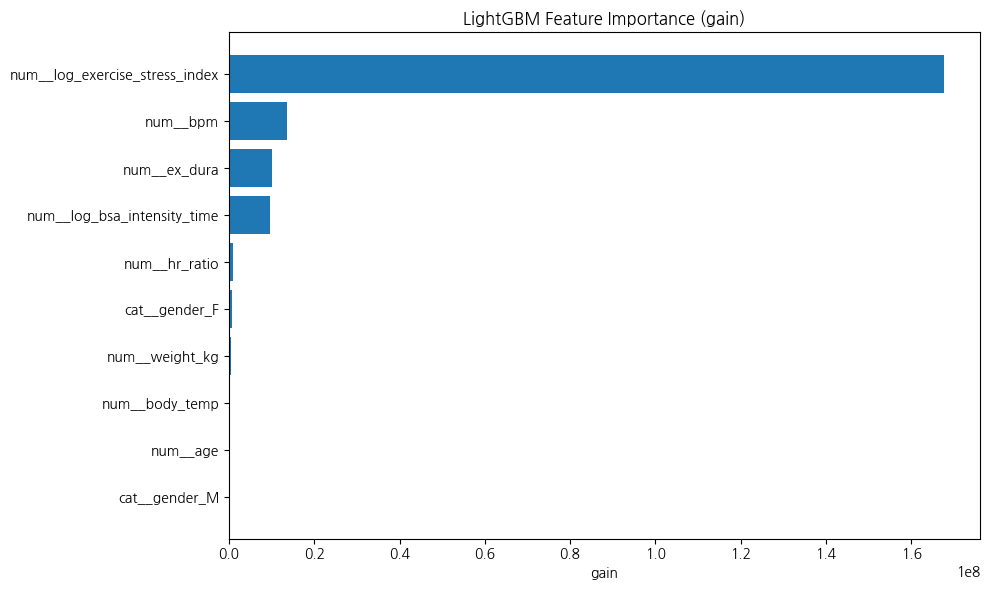

In [ ]:
best_params = study_lgbm.best_trial.params

best_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LGBMRegressor(**best_params, random_state=RANDOM_STATE, verbose=-1))
])

best_pipe.fit(X_train, y_train)

# 1) 파이프라인에서 전처리기와 모델 분리
preprocess = best_pipe.named_steps["prep"]
lgbm_model = best_pipe.named_steps["model"]

# 2) 전처리 결과 feature name 얻기 (sklearn 1.0+)
feature_names = preprocess.get_feature_names_out()

# 3) 중요도 얻기 (gain 기준)
gain = lgbm_model.booster_.feature_importance(importance_type="gain")

# 4) f인덱스 -> feature_names 매핑
imp = (pd.DataFrame({"feature": feature_names, "gain": gain})
         .sort_values("gain", ascending=False)
         .head(10))

# 5) plot
plt.figure(figsize=(10, 6))
plt.barh(imp["feature"][::-1], imp["gain"][::-1])
plt.title("LightGBM Feature Importance (gain)")
plt.xlabel("gain")
plt.tight_layout()
plt.show()

# GridSearchCV

In [ ]:
# 1) outlier flag -> sample_weight (flag=1이면 0.5)
def make_sample_weight_from_flag(flag, w_bad=0.5):
    w = np.ones(len(flag), dtype=float)
    w[np.asarray(flag) == 1] = w_bad
    return w

# 이상치 샘플 가중치 조정
w_train = make_sample_weight_from_flag(flag_train, w_bad=0.5)

# 2) StratifiedKFold를 "flag 기준"으로 split 생성
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(X_train, flag_train))

# 3) 인코딩
cat_cols = ["gender"]  # 범주형 컬럼 지정
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# 4) 하이퍼파라미터 그리드
fixed_params = {
    "num_leaves": 65,
    "feature_fraction": 0.84,
    "bagging_fraction": 0.63,
    "bagging_freq": 7,
    "reg_alpha": 0.0,        # 사실상 영향 없음
    "reg_lambda": 0.0,
    "objective": "regression",
    "random_state": RANDOM_STATE,
    "verbose": -1
}

pipe = Pipeline([
    ("prep", preprocess),
    ("model", LGBMRegressor(**fixed_params)),
])

param_grid = {
    "model__min_child_samples": [3,4,5,6,7,8,9,10,12,15],    # 과적합 억제의 핵심
    "model__max_depth": [3],    # 3이 베스트지만 ±1 확인
    "model__learning_rate": [0.09],
    "model__n_estimators":  [3800, 4200, 4600, 5000],   # trade-off 확인
}


In [ ]:
# GridSearchCV
print("\nTuning LightGBM Regressor...")
print("(교차검증 수행 중...)\n")

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,              # <- flag stratify 적용된 split
    n_jobs=-1,
    verbose=2
)

# 5) sample_weight는 Pipeline의 "model step"에 전달해야 함
gscv.fit(X_train, y_train, model__sample_weight=w_train)

print("Best RMSE:", -gscv.best_score_)
print("Best params:", gscv.best_params_)
print("\nGridSearchCV 완료!")


Tuning LightGBM Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RMSE: 1.3092912754661163
Best params: {'model__learning_rate': 0.09, 'model__max_depth': 3, 'model__min_child_samples': 5, 'model__n_estimators': 5000}

GridSearchCV 완료!


In [ ]:
# 최적 모델 추출
best_reg = gscv.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {gscv.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in gscv.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): -1.3093

Best Parameters:
  model__learning_rate: 0.09
  model__max_depth: 3
  model__min_child_samples: 5
  model__n_estimators: 5000


In [ ]:
# 상위 3개 결과
cv_results = pd.DataFrame(gscv.cv_results_)
top_results = cv_results.nlargest(3, 'mean_test_score')[[
    'param_model__n_estimators',
    'param_model__learning_rate',
    'param_model__max_depth',
    'param_model__min_child_samples',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 3개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 3개 파라미터 조합:
 param_model__n_estimators  param_model__learning_rate  param_model__max_depth  param_model__min_child_samples  mean_test_score  std_test_score
                      5000                        0.09                       3                               5        -1.309291        0.070508
                      5000                        0.09                       3                               4        -1.312010        0.079031
                      5000                        0.09                       3                               9        -1.315743        0.099509


In [ ]:
# 테스트 데이터 예측
y_pred = best_reg.predict(X_valid)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print(f"Valid RMSE: {rmse:.4f}")
print(f"Valid R2 Score: {r2:.4f}")

Valid RMSE: 1.2606
Valid R2 Score: 0.9996


In [ ]:
# 과적합 여부 확인: CV RMSE는 좋은데 holdout RMSE가 확 튄다 → 과적합 가능성↑. 비슷하면 문제 없음
pred_valid = best_reg.predict(X_valid)
rmse_valid = np.sqrt(np.mean((y_valid - pred_valid)**2))
print(f"Holdout RMSE: {rmse_valid}")

Holdout RMSE: 1.2605985883273054


                             Feature  Importance
remainder__log_exercise_stress_index        5064
                 remainder__hr_ratio        4285
   remainder__log_bsa_intensity_time        4249
                      remainder__bmi        3735
                      remainder__bpm        3516
                      remainder__age        2747
                remainder__weight_kg        2563
                  remainder__ex_dura        2318
                remainder__body_temp        2239
                remainder__height_cm        1546
                       cat__gender_F        1091
                       cat__gender_M         221

피처 중요도 순위:
                             Feature  Importance
remainder__log_exercise_stress_index        5064
                 remainder__hr_ratio        4285
   remainder__log_bsa_intensity_time        4249
                      remainder__bmi        3735
                      remainder__bpm        3516
                      remainder__age        2747
        

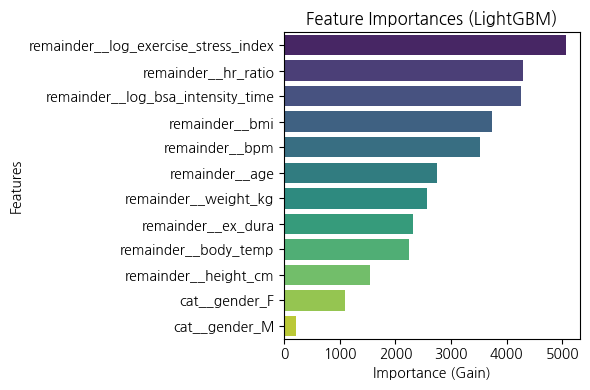

In [ ]:
# 피처 중요도 추출
lgbm = best_reg.named_steps["model"]
importances = lgbm.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
# 1) preprocessor 꺼내기
pre = best_reg.named_steps["prep"]

# 2) 변환 후 피처명 꺼내기
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    # 구버전 호환: ColumnTransformer 내부에서 OHE만 따로 접근해야 할 수 있음
    feature_names = np.arange(len(best_reg.named_steps["model"].feature_importances_)).astype(str)

# 3) 중요도 정렬
lgbm = best_reg.named_steps["model"]
importances = lgbm.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(30).to_string(index=False))

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (LightGBM)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# 테스트 데이터 로드
calories_test_data = pd.read_csv("/content/final_test.csv")
calories_test_data.columns = [c.strip() for c in calories_test_data.columns]    # 컬럼명 앞/뒤 공백 제거
X_test = calories_test_data

# 데이터 확인
print(f"데이터 크기: {X_test.shape}")
display(X_test.info())
dup_rows = X_test[X_test.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")

데이터 크기: (7500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   bpm                        7500 non-null   float64
 2   body_temp                  7500 non-null   float64
 3   hr_ratio                   7500 non-null   float64
 4   age                        7500 non-null   int64  
 5   gender                     7500 non-null   object 
 6   height_cm                  7500 non-null   float64
 7   weight_kg                  7500 non-null   float64
 8   bmi                        7500 non-null   float64
 9   log_exercise_stress_index  7500 non-null   float64
 10  log_bsa_intensity_time     7500 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 644.7+ KB


None

중복 확인:
Empty DataFrame
Columns: [ex_dura, bpm, body_temp, hr_ratio, age, gender, height_cm, weight_kg, bmi, log_exercise_stress_index, log_bsa_intensity_time]
Index: []


In [ ]:
# 테스트 데이터 예측
final_pred = best_reg.predict(X_test)

In [ ]:
# 제출 파일 제작
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred
submission.to_csv('./submit.csv', index = False, encoding="utf-8")